# Занятие 6. Классификация и кластеризация

На прошлых занятиях мы учились предсказывать **числа** — это задача регрессии.  

Сегодня переходим к другим задачам: предсказывать **категории** и искать **скрытую структуру** в данных.


In [19]:
# базовые импорты
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# настройки
warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 100
sns.set_style('whitegrid')
np.random.seed(42)


---
## Часть I. Задача классификации

### Регрессия vs классификация

| | Регрессия | Классификация |
|---|---|---|
| Целевая переменная | Непрерывная (число) | Категориальная (метка класса) |
| Пример задачи | Предсказать цену квартиры | Одобрить кредит или нет |
| Метрика качества | RMSE, R² | Accuracy, Precision, Recall |

**Бинарная классификация** — два класса: 0 и 1 (negative / positive).  
**Многоклассовая** — три и более классов (цифра 0–9, вид цветка и т.д.).

> Мы сосредоточимся на бинарной классификации, как на самом простом, но очень распространённом типе классификации.


Рассмотрим наглядный пример, иллюстрирующий различие задач регрессии и классификации:

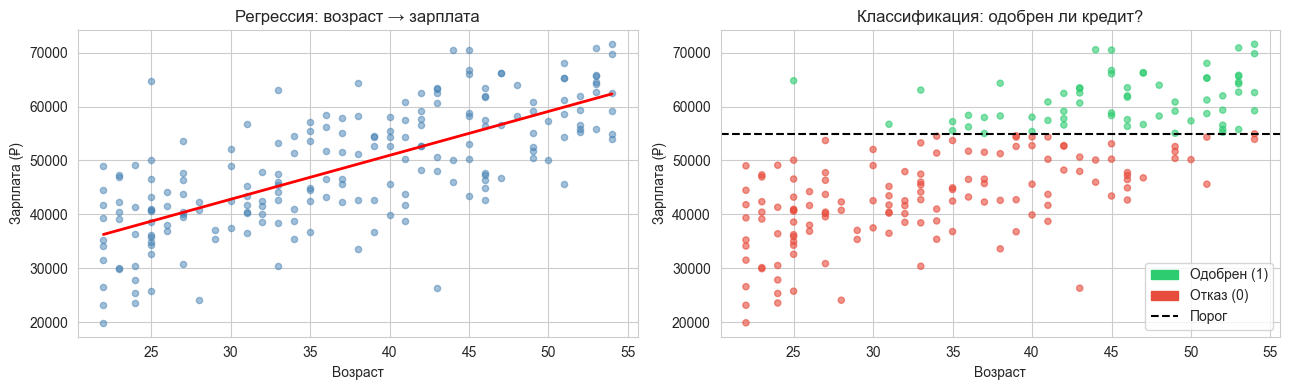

In [20]:
# Наглядный пример: регрессия vs классификация на одних данных
np.random.seed(0)
age = np.random.randint(22, 55, 200)
salary = 20000 + age * 800 + np.random.normal(0, 8000, 200)
loan_approved = (salary > 55000).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Регрессия: предсказываем зарплату
axes[0].scatter(age, salary, alpha=0.5, color='steelblue', s=20)
m, b = np.polyfit(age, salary, 1)
axes[0].plot(sorted(age), [m*a + b for a in sorted(age)], 'r-', linewidth=2)
axes[0].set_title('Регрессия: возраст → зарплата', fontsize=12)
axes[0].set_xlabel('Возраст')
axes[0].set_ylabel('Зарплата (₽)')

# Классификация: одобрен ли кредит
colors = ['#e74c3c' if l == 0 else '#2ecc71' for l in loan_approved]
axes[1].scatter(age, salary, c=colors, alpha=0.6, s=20)
axes[1].axhline(55000, color='black', linestyle='--', linewidth=1.5, label='Граница решения')
axes[1].set_title('Классификация: одобрен ли кредит?', fontsize=12)
axes[1].set_xlabel('Возраст')
axes[1].set_ylabel('Зарплата (₽)')
axes[1].legend()
# Легенда вручную
from matplotlib.patches import Patch
axes[1].legend(handles=[
    Patch(color='#2ecc71', label='Одобрен (1)'),
    Patch(color='#e74c3c', label='Отказ (0)'),
    plt.Line2D([0],[0], color='black', linestyle='--', label='Порог')
])

plt.tight_layout()
plt.show()

---
## Данные на лекции: датасет Titanic, встроенный в seaborn

Мы будем использовать реальные данные о катастрофе на "Титанике" на протяжении всей лекции. 
 
**Задача:** предсказать, выжил ли пассажир (1) или нет (0) по его характеристикам.

Признаки: класс билета (`pclass`), пол (`sex`), возраст (`age`), цена билета (`fare`).


In [21]:
# Загружаем датасет
df = sns.load_dataset('titanic')

df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [22]:
# Оставляем нужные столбцы и убираем пропуски
df_clean = df[['survived', 'pclass', 'sex', 'age', 'fare']].dropna()

# Кодируем пол: male=1, female=0
df_clean = df_clean.copy()
df_clean['sex'] = (df_clean['sex'] == 'male').astype(int)

print(f"Размер датасета: {df_clean.shape[0]} пассажиров, {df_clean.shape[1]-1} признака")
print(df_clean['survived'].value_counts()) # обратите внимание на баланс классов
df_clean.head()


Размер датасета: 714 пассажиров, 4 признака
survived
0    424
1    290
Name: count, dtype: int64


,survived,pclass,sex,age,fare
0,0,3,1,22.0,7.2500
1,1,1,0,38.0,71.2833
2,1,3,0,26.0,7.9250
3,1,1,0,35.0,53.1000
4,0,3,1,35.0,8.0500


---
## Ещё раз напомним правило перед началом: делим данные на train и test

Прежде чем обучать любую модель — вспомним ключевой принцип:

```
Данные
  ├── Train (обучение, ~80%) → модель учится на этих данных
  └── Test  (оценка,   ~20%) → проверка на "незнакомых" данных
```

**Зачем это нужно?**  
Если оценивать модель на тех же данных, на которых она обучалась — мы получим завышенный результат.  
Модель может просто «запомнить» ответы, а не научиться обобщать.

```python
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
#                                                               ↑ 20% уходит в тест
```

> ⚠️ `random_state=42` — фиксирует случайность, чтобы было одинаковое разбиение при повторных запусках.



In [23]:
from sklearn.model_selection import train_test_split


# Делим на признаки и целевую переменную
X_titanic = df_clean[['pclass', 'sex', 'age', 'fare']].values
y_titanic = df_clean['survived'].values

# Делим на train и test
X_train, X_test, y_train, y_test = train_test_split(X_titanic, y_titanic, test_size=0.25, random_state=42)
print(f"Train: {X_train.shape[0]} пассажиров")
print(f"Test:  {X_test.shape[0]} пассажиров")

Train: 535 пассажиров
Test:  179 пассажиров


---
## Логистическая регрессия

### Почему не линейная регрессия?

Линейная регрессия предсказывает число на числовой прямой — она может выдать 1.7 или −0.3.

Для бинарной классификации нам нужна **вероятность принадлежности к классу**: число от 0 до 1.

### Сигмоида - функция, задающая логистическую регрессию

$$\sigma(z) = \frac{1}{1 + e^{-z}}$$

- При $z \to +\infty$: $\sigma(z) \to 1$
- При $z \to -\infty$: $\sigma(z) \to 0$
- При $z = 0$: $\sigma(z) = 0.5$

Где $z = w_0 + w_1 x_1 + w_2 x_2 + \ldots$ — линейная комбинация признаков (как в линейной регрессии).

### Итоговая формула

$$P(y=1 \mid x) = \sigma(w^T x) = \frac{1}{1 + e^{-(w_0 + w_1 x_1 + \ldots + w_n x_n)}}$$

Модель выдаёт **вероятность** принадлежности к классу 1.
Затем применяется **порог** (по умолчанию 0.5): если $P > 0.5$ → класс 1, иначе → класс 0.

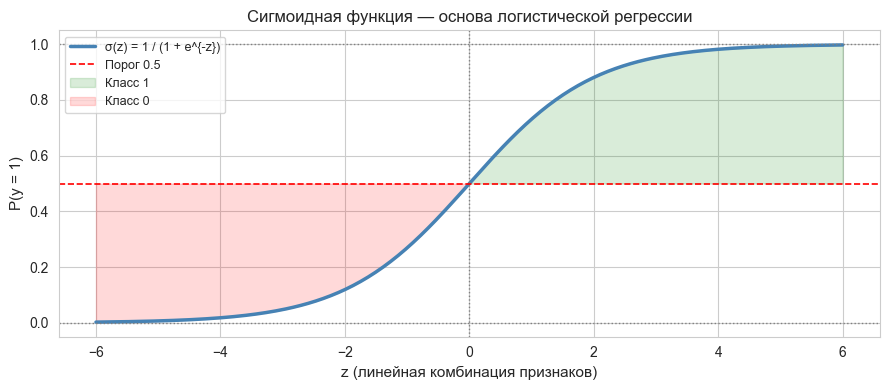

Несколько примеров:
  z = -4  →  P(y=1) = 0.018  →  класс 0
  z = -2  →  P(y=1) = 0.119  →  класс 0
  z = +0  →  P(y=1) = 0.500  →  класс 0
  z = +1  →  P(y=1) = 0.731  →  класс 1
  z = +2  →  P(y=1) = 0.881  →  класс 1
  z = +4  →  P(y=1) = 0.982  →  класс 1


In [24]:
# Визуализация сигмоиды
z = np.linspace(-6, 6, 300)
sigma = 1 / (1 + np.exp(-z))

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(z, sigma, 'steelblue', linewidth=2.5, label='σ(z) = 1 / (1 + e^{-z})')
ax.axhline(0.5, color='red', linestyle='--', linewidth=1.2, label='Порог 0.5')
ax.axhline(1.0, color='gray', linestyle=':', linewidth=1)
ax.axhline(0.0, color='gray', linestyle=':', linewidth=1)
ax.axvline(0, color='gray', linestyle=':', linewidth=1)
ax.fill_between(z, 0.5, sigma, where=(sigma > 0.5), alpha=0.15, color='green', label='Класс 1')
ax.fill_between(z, sigma, 0.5, where=(sigma < 0.5), alpha=0.15, color='red', label='Класс 0')
ax.set_xlabel('z (линейная комбинация признаков)', fontsize=11)
ax.set_ylabel('P(y = 1)', fontsize=11)
ax.set_title('Сигмоидная функция — основа логистической регрессии', fontsize=12)
ax.legend(fontsize=9)
ax.set_ylim(-0.05, 1.05)
plt.tight_layout()
plt.show()

print("Несколько примеров:")
for z_val in [-4, -2, 0, 1, 2, 4]:
    p = 1 / (1 + np.exp(-z_val))
    print(f"  z = {z_val:+d}  →  P(y=1) = {p:.3f}  →  класс {'1' if p > 0.5 else '0'}")

### Интерпретация коэффициентов

Коэффициенты логистической регрессии показывают **направление и силу влияния** признака:

- **Положительный коэффициент** → признак увеличивает вероятность класса 1
- **Отрицательный коэффициент** → признак уменьшает вероятность класса 1
- **Близкий к нулю** → признак слабо влияет на предсказание

> ⚠️ Сравнивать коэффициенты по величине можно **только если признаки масштабированы** (StandardScaler).  
> Без масштабирования признак с большим диапазоном значений автоматически получает маленький коэффициент — это не значит, что он неважен.

### Попробуем построить предсказание на данных с "Титаника".

In [25]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# Обучаем логистическую регрессию на данных Titanic
scaler_lr = StandardScaler() # не забывайте масштабировать данные!!!
X_train_scaled = scaler_lr.fit_transform(X_train)   # ← fit только на train!
X_test_scaled  = scaler_lr.transform(X_test)         # ← применяем те же параметры к test

model_lr = LogisticRegression(random_state=42) # инициализируем модель
model_lr.fit(X_train_scaled, y_train)           # фитим её на наши данные

# выведем коэффициенты логистической регрессии
feature_names = ['pclass', 'sex (male=1)', 'age', 'fare']
print("Коэффициенты логистической регрессии (после масштабирования):")
for name, coef in zip(feature_names, model_lr.coef_[0]):
    
    print(f"  {name:20s}: {coef:+.3f}")

Коэффициенты логистической регрессии (после масштабирования):
  pclass              : -1.058
  sex (male=1)        : -1.236
  age                 : -0.629
  fare                : +0.000


**Что мы видим:**  
Проанализируйте, как коэффициенты модели соотносятся с реальными данными о спасённых на "Титанике"?

---
## Метрики качества классификации

### Матрица ошибок (Confusion Matrix)

Разберём на примере Титаника: модель предсказывает, выжил пассажир (1) или нет (0).


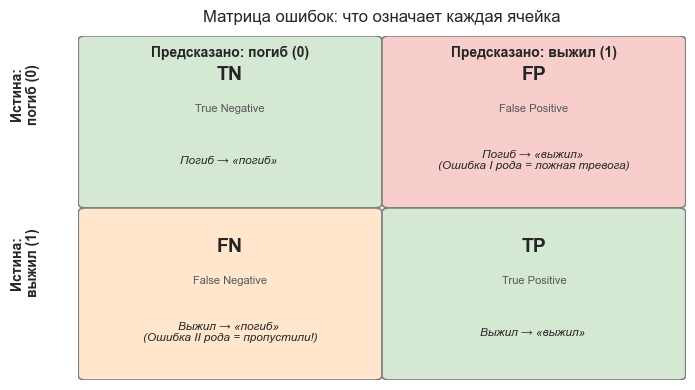

In [26]:
# Иллюстрация: структура матрицы ошибок на примере Титаника
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

fig, ax = plt.subplots(figsize=(7, 4))
ax.set_xlim(0, 4); ax.set_ylim(0, 4)
ax.axis('off')

# Цвета и содержимое ячеек
cells_data = [
    # (x, y, цвет фона, аббр., полное название, пример)
    (0, 2, '#d5e8d4', 'TN', 'True Negative',  'Погиб → «погиб» '),
    (2, 2, '#f8cecc', 'FP', 'False Positive', 'Погиб → «выжил» \n(Ошибка I рода = ложная тревога)'),
    (0, 0, '#ffe6cc', 'FN', 'False Negative', 'Выжил → «погиб» \n(Ошибка II рода = пропустили!)'),
    (2, 0, '#d5e8d4', 'TP', 'True Positive',  'Выжил → «выжил» '),
]

for (x, y, color, abbr, name, example) in cells_data:
    rect = mpatches.FancyBboxPatch((x+0.05, y+0.05), 1.9, 1.9,
                                    boxstyle="round,pad=0.05",
                                    facecolor=color, edgecolor='gray', linewidth=1.2)
    ax.add_patch(rect)
    ax.text(x+1, y+1.55, abbr,  ha='center', va='center', fontsize=14, fontweight='bold')
    ax.text(x+1, y+1.15, name,  ha='center', va='center', fontsize=8,  color='#555555')
    ax.text(x+1, y+0.55, example, ha='center', va='center', fontsize=8.5, style='italic')

# Подписи осей
ax.text(1.0, 3.75, 'Предсказано: погиб (0)',  ha='center', fontsize=10, fontweight='bold')
ax.text(3.0, 3.75, 'Предсказано: выжил (1)', ha='center', fontsize=10, fontweight='bold')
ax.text(-0.35, 1.0, 'Истина:\nвыжил (1)',  ha='center', fontsize=10, fontweight='bold', rotation=90)
ax.text(-0.35, 3.0, 'Истина:\nпогиб (0)', ha='center', fontsize=10, fontweight='bold', rotation=90)

ax.set_title('Матрица ошибок: что означает каждая ячейка', fontsize=12, pad=10)
plt.tight_layout()
plt.show()



| Термин | Расшифровка | На Титанике |
|---|---|---|
| **TP** | True Positive | Выжил — предсказали «выжил» ✓ |
| **TN** | True Negative | Погиб — предсказали «погиб» ✓ |
| **FP** | False Positive | Погиб — предсказали «выжил» ✗ (ложная тревога) |
| **FN** | False Negative | Выжил — предсказали «погиб» ✗ (пропустили выжившего) |


### Как запомнить, чем отличаются ошибки 1 и 2 рода?

![image](https://sun9-43.userapi.com/s/v1/ig2/O4FMg6qziXYPUhq9NQaRYOPs26xcZ_rv5wZxBMpIE2oQclRBF75KBA8HHyx9viWeLYeXyz88NxiZ48fSDHuUOgSO.jpg?quality=95&as=32x24,48x36,72x54,108x81,160x120,240x180,360x269,480x359,540x404,600x449&from=bu&cs=600x0)

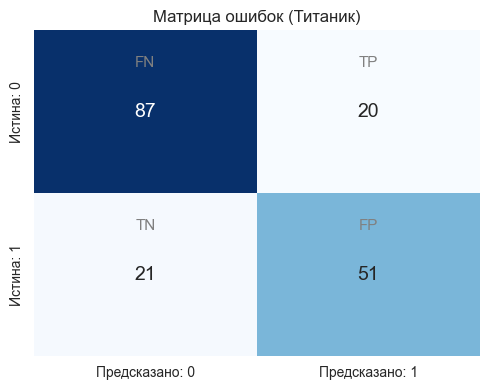

TN=87  FP=20  FN=21  TP=51


In [27]:
# посмотрим результаты нашей классификации
from sklearn.metrics import confusion_matrix

y_test_proba = model_lr.predict_proba(X_test_scaled)[:, 1] # обратите внимание - предсказываем вероятности - proba!!!
y_test_pred = (y_test_proba >= 0.5).astype(int) # классифицируем к класс 1 или 0 по порогу 0.5

cm2 = confusion_matrix(y_test, y_test_pred)

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm2, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Предсказано: 0', 'Предсказано: 1'],
            yticklabels=['Истина: 0', 'Истина: 1'],
            annot_kws={'size': 14})
ax.set_title('Матрица ошибок (Титаник)', fontsize=12)
ax.text(0.25, 0.4, 'TN', color='gray', fontsize=11, ha='center', va='center', transform=ax.transAxes)
ax.text(0.75, 0.4, 'FP', color='gray', fontsize=11, ha='center', va='center', transform=ax.transAxes)
ax.text(0.25, 0.9, 'FN', color='gray', fontsize=11, ha='center', va='center', transform=ax.transAxes)
ax.text(0.75, 0.9, 'TP', color='gray', fontsize=11, ha='center', va='center', transform=ax.transAxes)
plt.tight_layout()
plt.show()

TN, FP, FN, TP = cm2[0,0], cm2[0,1], cm2[1,0], cm2[1,1] # явное извлечение значений из матрицы ошибок
print(f"TN={TN}  FP={FP}  FN={FN}  TP={TP}")



**Как читать матрицу:**  
Строки — что было на самом деле, столбцы — что предсказала модель. Цифры по диагонали (TN и TP) — правильные ответы, вне диагонали (FP и FN) — ошибки.  


### Основные метрики

$$\text{Accuracy} = \frac{TP + TN}{TP + TN + FP + FN}$$

> Как правильно называть на русском: **Доля правильных ответов**. 
>
> **НЕ ВЕРНО НАЗЫВАТЬ ЕЁ ТОЧНОСТЬ!!!**
> 
> **Обманчива при несбалансированных классах:** если, например, представителей класс 1 намного больше (например, 95%) в выборке, модель, всегда предсказывающая класс 1, даст accuracy = 0.95 — без всяких знаний о конкретном пассажире.
>
> Что делать? При сильном дисбалансе: `class_weight='balanced'` в `LogisticRegression`

$$\text{Precision} = \frac{TP}{TP + FP}$$

> Как правильно называть на русском: **Точность**. 
> Пример на нашем датасете: Из всех, кого модель назвала «выжившими», сколько реально выжили?  
> Важна, когда **дорого ошибиться в сторону FP** — например, ложно сообщить семье, что человек спасён.

$$\text{Recall} = \frac{TP}{TP + FN}$$

> Как правильно называть на русском: **Полнота**. 
> Из всех реально выживших, скольких модель нашла?  
> Важна, когда **дорого пропустить выжившего** — в спасательной операции лучше проверить лишний раз, чем оставить человека без помощи.

### Компромисс Precision / Recall

Снижение порога (< 0.5) → модель чаще предсказывает «1» → **Recall растёт, Precision падает**.  
Повышение порога (> 0.5) → модель реже предсказывает «1» → **Precision растёт, Recall падает**.

---
### Как выбрать нужную метрику? Практическое правило

| Сфера применения | Что страшнее | Приоритетная метрика |
|---|---|---|
| Онкодиагностика, COVID-тест | Пропустить больного (FN) | **Recall** |
| Спам-фильтр | Удалить важное письмо (FP) | **Precision** |
| Мошеннические транзакции | Пропустить мошенника (FN) | **Recall** |
| Рекомендательная система | Показать нерелевантное (FP) | **Precision** |

> **Ключевой вопрос:** «Что дороже — ложная тревога (FP) или пропущенный случай (FN)?»  
> Ответ на этот вопрос определяет, какую метрику оптимизировать — и это **важнее выбора алгоритма**.

Есть и другие метрики оценки качества классификации, но мы остановимся на этих.



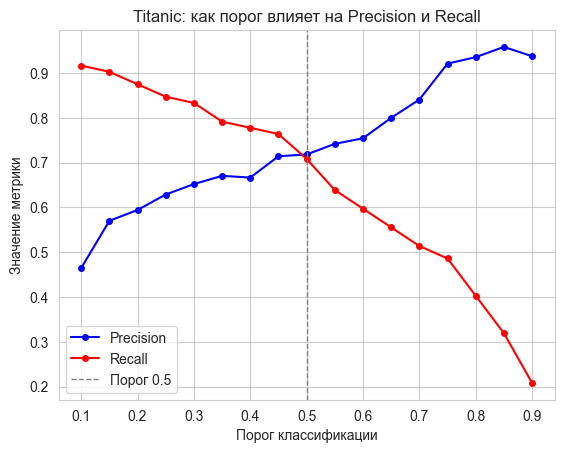

In [28]:
from sklearn.metrics import accuracy_score, precision_score, recall_score # встроенные функции для подсчёта метрик
# Метрики логрег на Titanic + влияние порога на Precision/Recall
y_test_proba = model_lr.predict_proba(X_test_scaled)[:, 1]

thresholds = np.arange(0.1, 0.91, 0.05)
precisions, recalls = [], []
for t in thresholds:
    pred = (y_test_proba >= t).astype(int)
    precisions.append(precision_score(y_test, pred, zero_division=0))
    recalls.append(recall_score(y_test, pred))

plt.plot(thresholds, precisions, 'b-o', markersize=4, label='Precision')
plt.plot(thresholds, recalls, 'r-o', markersize=4, label='Recall')
plt.axvline(0.5, color='gray', linestyle='--', linewidth=1, label='Порог 0.5')
plt.xlabel('Порог классификации')
plt.ylabel('Значение метрики')
plt.title('Titanic: как порог влияет на Precision и Recall')
plt.legend()


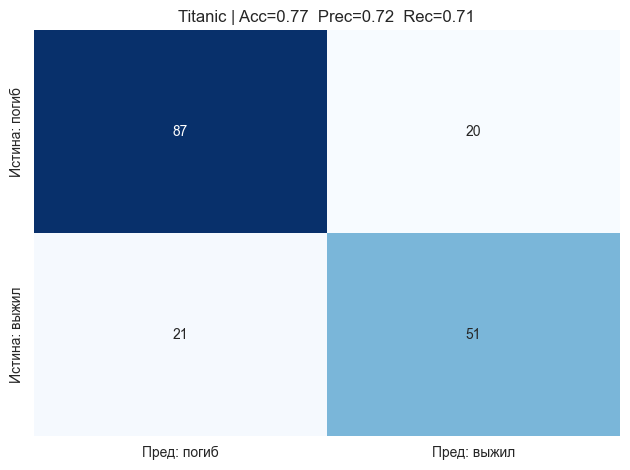

Accuracy  = (TP+TN)/всего = (51+87)/179 = 0.771
Precision = TP/(TP+FP)   = 51/(51+20) = 0.718
Recall    = TP/(TP+FN)   = 51/(51+21) = 0.708


In [29]:


y_test_pred = (y_test_proba >= 0.5).astype(int)
cm_t = confusion_matrix(y_test, y_test_pred)
sns.heatmap(cm_t, annot=True, fmt='d', cmap='Blues', cbar=False, 
            xticklabels=['Пред: погиб', 'Пред: выжил'],
            yticklabels=['Истина: погиб', 'Истина: выжил'])

# вычисление метрик через встроенные функции
acc_lr  = accuracy_score(y_test, y_test_pred)
prec_lr = precision_score(y_test, y_test_pred)
rec_lr  = recall_score(y_test, y_test_pred)
plt.title(f'Titanic | Acc={acc_lr:.2f}  Prec={prec_lr:.2f}  Rec={rec_lr:.2f}')
plt.tight_layout()
plt.show()

# явное вычисление метрик
TN, FP, FN, TP = cm2[0,0], cm2[0,1], cm2[1,0], cm2[1,1] # явное извлечение значений из матрицы ошибок
print(f"Accuracy  = (TP+TN)/всего = ({TP}+{TN})/{len(y_test)} = {(TP+TN)/len(y_test):.3f}")
print(f"Precision = TP/(TP+FP)   = {TP}/({TP}+{FP}) = {TP/(TP+FP):.3f}")
print(f"Recall    = TP/(TP+FN)   = {TP}/({TP}+{FN}) = {TP/(TP+FN):.3f}")



> Вопрос для обсуждения:
Если бы мы создавали систему помощи при эвакуации, что важнее — не пропустить выжившего (высокий Recall) или не тратить ресурсы на ложные тревоги (высокий Precision)?

---
## ROC-кривая и AUC

### Идея

ROC-кривая показывает, как меняется соотношение **TPR** (True Positive Rate = Recall) и **FPR** (False Positive Rate) при изменении порога классификации от 1 до 0.

$$TPR = \frac{TP}{TP + FN} $$

$$FPR = \frac{FP}{FP + TN}$$

### AUC — площадь под кривой

| AUC | Интерпретация |
|---|---|
| 1.0 | Идеальная модель |
| 0.9–1.0 | Отличная |
| 0.8–0.9 | Хорошая |
| 0.7–0.8 | Приемлемая |
| 0.5 | Случайный классификатор (бесполезно) |
| < 0.5 | Хуже случайного (модель «перевёрнута») |

**Физический смысл AUC:** вероятность того, что случайно выбранный положительный пример получит более высокую оценку модели, чем случайно выбранный отрицательный.

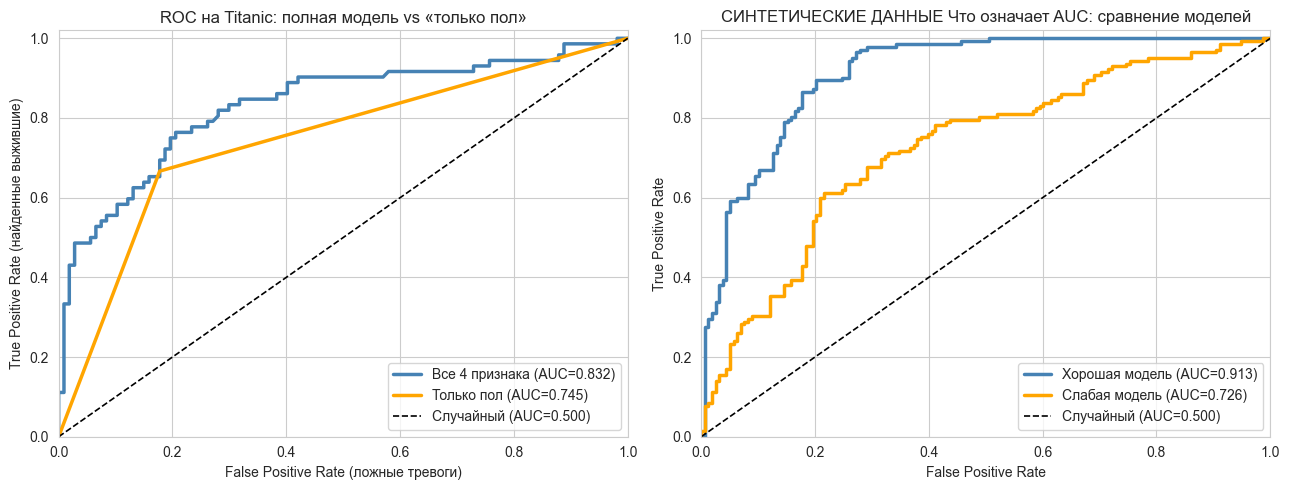

In [30]:
from sklearn.datasets import make_classification # для синтетической модели
from sklearn.metrics import roc_curve, roc_auc_score # встроенные метрики


# ROC-кривые: полная модель vs наивная (только пол) на Titanic
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- Левый график: Titanic, полная модель vs наивная (только признак sex) ---
X_naive_test = X_test_scaled[:, 1:2]   # только sex
naive_lr = LogisticRegression().fit(X_train_scaled[:, 1:2], y_train)

fpr_lr,  tpr_lr,  _ = roc_curve(y_test, model_lr.predict_proba(X_test_scaled)[:, 1])
fpr_naive, tpr_naive, _ = roc_curve(y_test, naive_lr.predict_proba(X_naive_test)[:, 1])
auc_lr  = roc_auc_score(y_test, model_lr.predict_proba(X_test_scaled)[:, 1])
auc_naive = roc_auc_score(y_test, naive_lr.predict_proba(X_naive_test)[:, 1])

axes[0].plot(fpr_lr,  tpr_lr,  'steelblue', linewidth=2.5,
             label=f'Все 4 признака (AUC={auc_lr:.3f})')
axes[0].plot(fpr_naive, tpr_naive, 'orange', linewidth=2.5,
             label=f'Только пол (AUC={auc_naive:.3f})')
axes[0].plot([0,1],[0,1], 'k--', linewidth=1.2, label='Случайный (AUC=0.500)')
axes[0].set_xlabel('False Positive Rate (ложные тревоги)')
axes[0].set_ylabel('True Positive Rate (найденные выжившие)')
axes[0].set_title('ROC на Titanic: полная модель vs «только пол»')
axes[0].legend(); axes[0].set_xlim(0,1); axes[0].set_ylim(0,1.02)

# --- Правый график: синтетика, хорошая vs слабая модель ---
X_roc, y_roc = make_classification(n_samples=1000, n_features=10, n_informative=5, random_state=42)
X_tr_r, X_te_r, y_tr_r, y_te_r = train_test_split(X_roc, y_roc, test_size=0.3, random_state=42)
sc_r = StandardScaler()
X_tr_rs = sc_r.fit_transform(X_tr_r); X_te_rs = sc_r.transform(X_te_r)

lr_good = LogisticRegression(C=10).fit(X_tr_rs, y_tr_r)
lr_weak = LogisticRegression(C=0.001).fit(X_tr_rs[:, :2], y_tr_r)
fpr_g, tpr_g, _ = roc_curve(y_te_r, lr_good.predict_proba(X_te_rs)[:, 1])
fpr_w, tpr_w, _ = roc_curve(y_te_r, lr_weak.predict_proba(X_te_rs[:, :2])[:, 1])
auc_g = roc_auc_score(y_te_r, lr_good.predict_proba(X_te_rs)[:, 1])
auc_w = roc_auc_score(y_te_r, lr_weak.predict_proba(X_te_rs[:, :2])[:, 1])

axes[1].plot(fpr_g, tpr_g, 'steelblue', linewidth=2.5, label=f'Хорошая модель (AUC={auc_g:.3f})')
axes[1].plot(fpr_w, tpr_w, 'orange', linewidth=2.5, label=f'Слабая модель (AUC={auc_w:.3f})')
axes[1].plot([0,1],[0,1], 'k--', linewidth=1.2, label='Случайный (AUC=0.500)')
axes[1].set_xlabel('False Positive Rate'); axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('СИНТЕТИЧЕСКИЕ ДАННЫЕ Что означает AUC: сравнение моделей')
axes[1].legend(); axes[1].set_xlim(0,1); axes[1].set_ylim(0,1.02)

plt.tight_layout()
plt.show()


**Что мы видим:**  
Левый график: полная модель (AUC ~0.85) заметно лучше наивной «только пол» (AUC ~0.82). Что это значит?

Правый график: чем «пузатее» кривая — тем лучше модель. Идеальная кривая шла бы по левому верхнему углу. 

AUC=0.5 — это прямая диагональ, то есть модель угадывает случайно.

**Ключевое преимущество AUC:** не зависит от выбранного порога. Если вы хотите сравнить две модели, не зная заранее, какой порог нужен — смотрите на AUC.


---
## Метод k ближайших соседей (KNN)

### Идея

KNN — «ленивый» алгоритм: он не строит явную модель. При предсказании для нового объекта:
1. Найти k ближайших объектов из обучающей выборки (обычно по евклидову расстоянию).
2. Посмотреть на их метки класса.
3. Вернуть **большинство** (для классификации) - самый популярный вариант.

$$\hat{y} = \text{mode}\{y_i : x_i \in \text{kNN}(x)\}$$

### Выбор k - количества соседей

| k | Проблема |
|---|---|
| Маленькое (k=1) | Переобучение: модель «запоминает» шум |
| Большое (k=N) | Недообучение: предсказывает всегда мажоритарный класс |
| Чётное | Возможна ничья → лучше нечётные k |

> Оптимальное k подбирают на **валидационной выборке** или через кросс-валидацию — не по тестовой!
Но это уже совсем другая история - курса "Машинное обучение"


### Визуализация KNN при разных k сначала на синтетических данных, т.к. выглядит нагляднее граница.

цветные точки - реальные метки класса.

цветной фон - класс, предсказанный моделью.

Визуализируем результат на **тренировочной выборке**

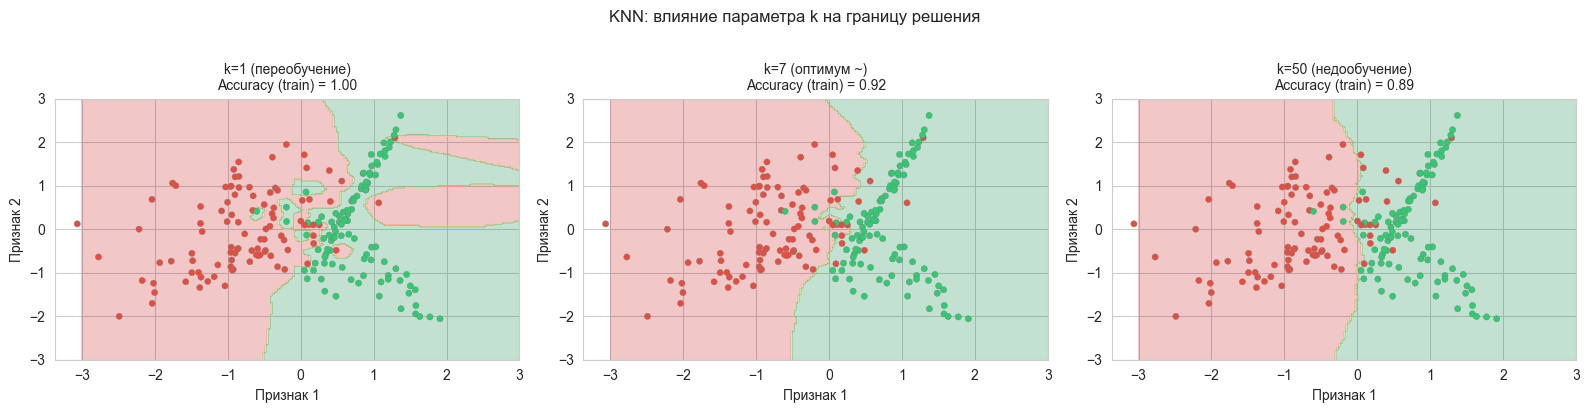

In [31]:
from sklearn.neighbors import KNeighborsClassifier

np.random.seed(0)
X_knn, y_knn = make_classification(n_samples=200, n_features=2, n_informative=2,
                                    n_redundant=0, random_state=0, class_sep=0.8)
scaler_knn = StandardScaler()
X_knn_s = scaler_knn.fit_transform(X_knn)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, k, title in zip(axes, [1, 7, 50],
                          ['k=1 (переобучение)', 'k=7 (оптимум ~)', 'k=50 (недообучение)']):
    knn_k = KNeighborsClassifier(n_neighbors=k).fit(X_knn_s, y_knn)

    # Сетка для отрисовки границы
    xx, yy = np.meshgrid(np.linspace(-3, 3, 200), np.linspace(-3, 3, 200))
    Z = knn_k.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

    ax.contourf(xx, yy, Z, alpha=0.25, cmap='RdYlGn')
    colors = ['#e74c3c' if c == 0 else '#2ecc71' for c in y_knn]
    ax.scatter(X_knn_s[:, 0], X_knn_s[:, 1], c=colors, s=20, edgecolors='gray', linewidths=0.3)
    acc_k = knn_k.score(X_knn_s, y_knn)
    ax.set_title(f'{title}\nAccuracy (train) = {acc_k:.2f}', fontsize=10)
    ax.set_xlabel('Признак 1')
    ax.set_ylabel('Признак 2')

plt.suptitle('KNN: влияние параметра k на границу решения', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

**Что мы видим:**  
При k=1 граница решения очень «рваная» — модель **запомнила** каждую точку, включая шум. Accuracy на обучающей выборке = 1.0, но на тесте она упадёт: это переобучение.  
При k=7 граница плавная и разумная.  
При k=50  — модель «усредняет» слишком много соседей и перестаёт различать классы в сложных зонах.

**Вывод:** k — это компромисс между гибкостью и устойчивостью модели. 

Есть различные способы подбора правильного k, причём его всегда подбирают на отдельной валидационной выборке, а не смотрят на тренировочную accuracy.

Но это уже материал следующего года, курса "Машинное обучение"

## Влияние масштабирования на KNN!!!

два признака с очень разными масштабами: возраст 20-65 vs зарплата 20000-120000 денег.


In [32]:
np.random.seed(42)
n = 300
age    = np.random.randint(20, 65, n).astype(float)
salary = np.random.uniform(20000, 120000, n)
y_cls  = ((age > 40) | (salary > 80000)).astype(int)

X_raw = np.column_stack([age, salary])

# Ещё раз: масштабируем (fit) только на train — чтобы test не "просочился" в параметры
X_tr_raw, X_te_raw, y_tr_c, y_te_c = train_test_split(X_raw, y_cls, test_size=0.3, random_state=42)
sc_knn = StandardScaler()
X_tr_sc = sc_knn.fit_transform(X_tr_raw)   # ← считаем μ и σ на TRAIN
X_te_sc = sc_knn.transform(X_te_raw)        # ← применяем те же μ, σ к TEST (не fit!)

knn_raw = KNeighborsClassifier(n_neighbors=5).fit(X_tr_raw, y_tr_c)
knn_sc  = KNeighborsClassifier(n_neighbors=5).fit(X_tr_sc, y_tr_c)

print(f"KNN без масштабирования: accuracy = {knn_raw.score(X_te_raw, y_te_c):.3f}")
print(f"KNN со StandardScaler:  accuracy = {knn_sc.score(X_te_sc, y_te_c):.3f}")



KNN без масштабирования: accuracy = 0.778
KNN со StandardScaler:  accuracy = 0.956


**Что мы видим:**  
Почему так отличаются доли правильных ответов?


### Применим kNN к задаче с "Титаником"


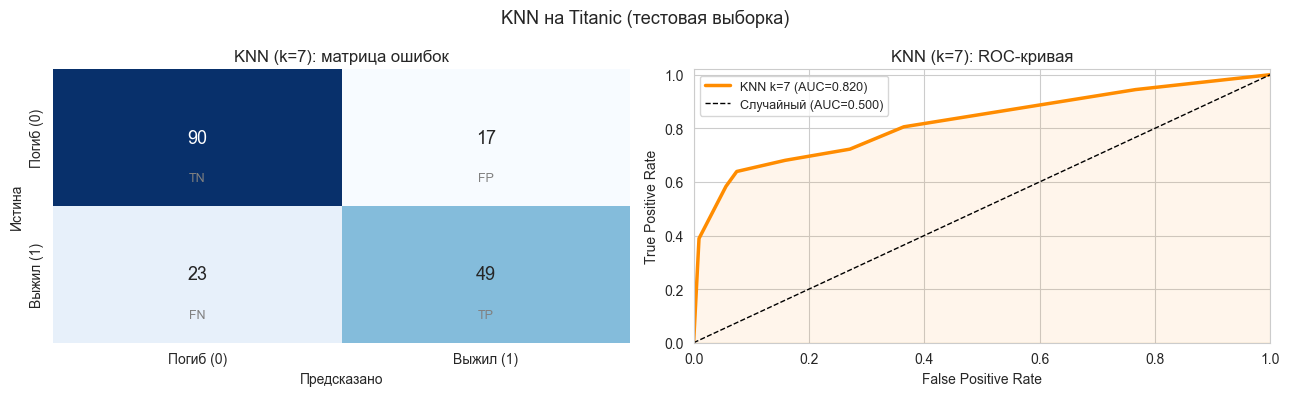

Accuracy:  0.777
Precision: 0.742
Recall:    0.681
AUC:       0.820


In [33]:
from sklearn.neighbors import KNeighborsClassifier

# KNN на Titanic
knn = KNeighborsClassifier(n_neighbors=7)
knn.fit(X_train_scaled, y_train)
y_pred_knn  = knn.predict(X_test_scaled)
y_proba_knn = knn.predict_proba(X_test_scaled)[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
labels = ['Погиб (0)', 'Выжил (1)']

# Матрица ошибок
cm_knn = confusion_matrix(y_test, y_pred_knn)
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[0],
            xticklabels=labels, yticklabels=labels, annot_kws={'size': 13})
axes[0].set_xlabel('Предсказано'); axes[0].set_ylabel('Истина')
axes[0].set_title('KNN (k=7): матрица ошибок')
for (row, col, label) in [(0,0,'TN'),(0,1,'FP'),(1,0,'FN'),(1,1,'TP')]:
    axes[0].text(col+0.5, row+0.82, label, ha='center', fontsize=9, color='gray')

# ROC-кривая
fpr_knn, tpr_knn, _ = roc_curve(y_test, y_proba_knn)
auc_knn = roc_auc_score(y_test, y_proba_knn)
axes[1].plot(fpr_knn, tpr_knn, 'darkorange', linewidth=2.5, label=f'KNN k=7 (AUC={auc_knn:.3f})')
axes[1].fill_between(fpr_knn, tpr_knn, alpha=0.08, color='darkorange')
axes[1].plot([0,1],[0,1], 'k--', linewidth=1, label='Случайный (AUC=0.500)')
axes[1].set_xlabel('False Positive Rate'); axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('KNN (k=7): ROC-кривая')
axes[1].legend(fontsize=9); axes[1].set_xlim(0,1); axes[1].set_ylim(0,1.02)

plt.suptitle('KNN на Titanic (тестовая выборка)', fontsize=13)
plt.tight_layout()
plt.show()

# Метрики под графиками
acc_knn  = accuracy_score(y_test, y_pred_knn)
prec_knn = precision_score(y_test, y_pred_knn)
rec_knn  = recall_score(y_test, y_pred_knn)
print(f"Accuracy:  {acc_knn:.3f}")
print(f"Precision: {prec_knn:.3f}")
print(f"Recall:    {rec_knn:.3f}")
print(f"AUC:       {auc_knn:.3f}")

Метрика      Логист. регрессия   KNN (k=7)
--------------------------------------------
Accuracy                 0.771       0.777
Precision                0.718       0.742
Recall                   0.708       0.681
AUC                      0.832       0.820


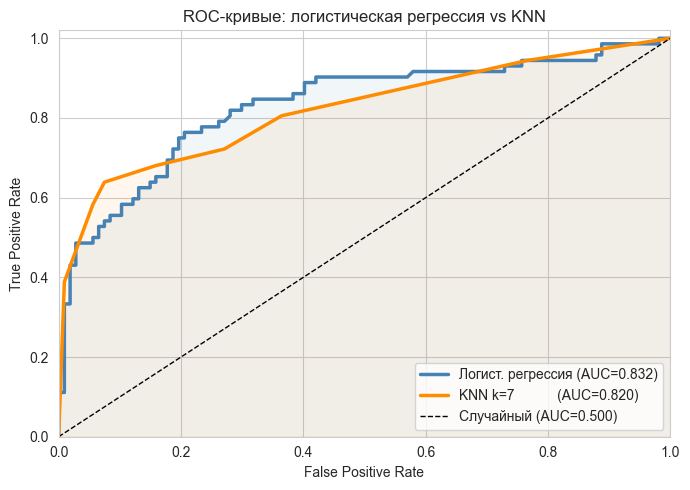

In [34]:
# Сравнение KNN vs логистическая регрессия

# Таблица метрик
print("=" * 44)
print(f"{'Метрика':<12} {'Логист. регрессия':>17} {'KNN (k=7)':>11}")
print("-" * 44)
for name, val_lr, val_knn in [
    ('Accuracy',  acc_lr,  acc_knn),
    ('Precision', prec_lr, prec_knn),
    ('Recall',    rec_lr,  rec_knn),
    ('AUC',       auc_lr,  auc_knn),
]:
    
    print(f"{name:<12} {val_lr:>17.3f} {val_knn:>11.3f}")
print("=" * 44)

# ROC-кривые на одном графике
plt.figure(figsize=(7, 5))
plt.plot(fpr_lr,  tpr_lr,  'steelblue',  linewidth=2.5, label=f'Логист. регрессия (AUC={auc_lr:.3f})')
plt.plot(fpr_knn, tpr_knn, 'darkorange', linewidth=2.5, label=f'KNN k=7           (AUC={auc_knn:.3f})')
plt.plot([0,1],[0,1], 'k--', linewidth=1, label='Случайный (AUC=0.500)')
plt.fill_between(fpr_lr,  tpr_lr,  alpha=0.07, color='steelblue')
plt.fill_between(fpr_knn, tpr_knn, alpha=0.07, color='darkorange')
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('ROC-кривые: логистическая регрессия vs KNN')
plt.legend(fontsize=10); plt.xlim(0,1); plt.ylim(0,1.02)
plt.tight_layout()
plt.show()

**Что мы видим:**  
Какая модель справилась лучше?

Почему на ROC-кривой для kNN меньше "ступенек"? Почему их столько?

---
## Часть II. Кластеризация — обучение без учителя

### Классификация vs кластеризация

| | Классификация | Кластеризация |
|---|---|---|
| Метки классов | Известны (обучение с учителем) | Неизвестны (без учителя) |
| Цель | Предсказать метку нового объекта | Найти структуру в данных |
| Оценка | Accuracy, Precision, Recall, AUC | Inertia, Silhouette score |
| Пример | Выжил или нет (Titanic) | Сегментация пассажиров по типу |

Кластеризация отвечает на вопрос: **«Есть ли в данных естественные группы?»** — без заранее известных правильных ответов.

**Практический пример:** представьте, что данные о пассажирах у нас есть, но колонки `survived` нет. Можем ли мы обнаружить, что пассажиры распадаются на группы? Кластеризация — инструмент для этого.


---
## Алгоритм k-means

### Алгоритм (4 шага)

1. **Инициализация:** случайно выбрать k точек как начальные центроиды.
2. **Присвоение:** каждую точку отнести к ближайшему центроиду.
3. **Обновление:** пересчитать центроиды как среднее точек своего кластера.
4. **Повторить** шаги 2–3 до сходимости (центроиды не двигаются).

### Целевая функция (inertia)

$$J = \sum_{k=1}^{K} \sum_{x_i \in C_k} \|x_i - \mu_k\|^2$$

k-means минимизирует суммарное квадратичное расстояние от точек до своих центроидов.

### Особенности и ограничения

- Нужно задать **k заранее** — это главный недостаток.
- Результат зависит от начальной инициализации → используйте `random_state`.
- Плохо работает с кластерами **непуклой формы** или **разного размера**.
- Чувствителен к масштабу → **обязательно масштабировать**.

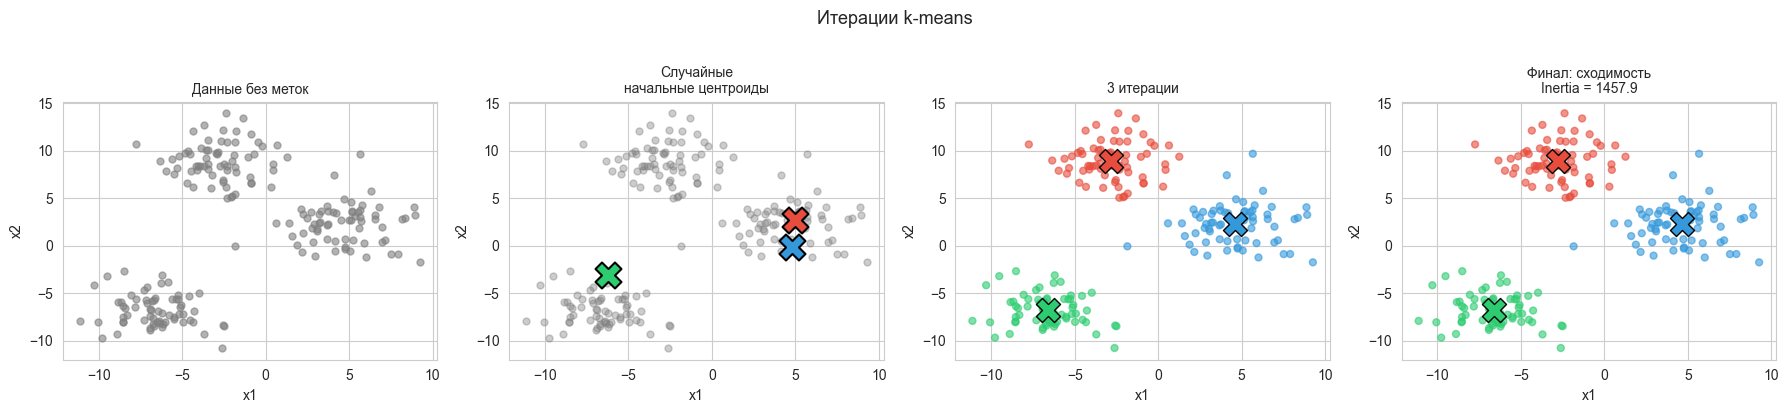

In [35]:
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans

# Визуализация k-means: как работает алгоритм

np.random.seed(42)
colors_1  = ['#e74c3c', '#2ecc71', '#3498db']
X_blob, y_blob = make_blobs(n_samples=200, centers=3, cluster_std=2, random_state=42)

fig, axes = plt.subplots(1, 4, figsize=(18, 4))

# Исходные данные без меток
axes[0].scatter(X_blob[:, 0], X_blob[:, 1], c='gray', s=25, alpha=0.6)
axes[0].set_title('Данные без меток', fontsize=10)

# Начальная инициализация
rng = np.random.default_rng(seed=7)
init_centers = X_blob[rng.choice(len(X_blob), size=3, replace=False)]
axes[1].scatter(X_blob[:, 0], X_blob[:, 1], c='gray', s=25, alpha=0.4)
for j, (cx, cy) in enumerate(init_centers):
    axes[1].scatter(cx, cy, marker='X', s=350, c=colors_1[j],
                    edgecolors='black', linewidths=1.5, zorder=5)
axes[1].set_title('Случайные\nначальные центроиды', fontsize=10)

# После нескольких итераций
km_5it = KMeans(n_clusters=3, max_iter=3, n_init=1, random_state=42).fit(X_blob)
c_map = {j: colors_1[j] for j in range(3)}
point_colors = [c_map[l] for l in km_5it.labels_]
axes[2].scatter(X_blob[:, 0], X_blob[:, 1], c=point_colors, s=25, alpha=0.6)
for j, (cx, cy) in enumerate(km_5it.cluster_centers_):
    axes[2].scatter(cx, cy, marker='X', s=300, c=colors_1[j], edgecolors='black', zorder=5)
axes[2].set_title('3 итерации', fontsize=10)

# Финал: сходимость
km_fin = KMeans(n_clusters=3, random_state=42, n_init=10).fit(X_blob) # вот пример полноценного использования

point_colors_fin = [c_map[l] for l in km_fin.labels_]
axes[3].scatter(X_blob[:, 0], X_blob[:, 1], c=point_colors_fin, s=25, alpha=0.6)
for j, (cx, cy) in enumerate(km_fin.cluster_centers_):
    axes[3].scatter(cx, cy, marker='X', s=300, c=colors_1[j], edgecolors='black', zorder=5)
axes[3].set_title(f'Финал: сходимость\nInertia = {km_fin.inertia_:.1f}', fontsize=10)

for ax in axes:
    ax.set_xlabel('x1')
    ax.set_ylabel('x2')

plt.suptitle('Итерации k-means', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

**Что мы видим:**  
На первой итерации центроиды (✕) стоят почти случайно — точки распределены неправильно. Уже к 3-й итерации кластеры начинают обретать форму. К финалу центроиды «осели» в центрах своих групп, и inertia (суммарное расстояние до центроидов) стабилизировалась.

Именно поэтому нужен `n_init=10`: алгоритм запускается 10 раз с разными начальными точками и возвращает лучший результат — с наименьшей inertia.


### Метод локтя — как выбрать k?

Строим зависимость inertia от k. Inertia всегда убывает с ростом k (при k=N каждая точка — свой кластер, inertia=0).

Ищем **«локоть»** — точку, где убывание резко замедляется. Это и есть оптимальное k.

> Метод субъективен. В реальных задачах «локоть» бывает нечётким.
Дополнительно используют **Silhouette score**. И здравый смысл.

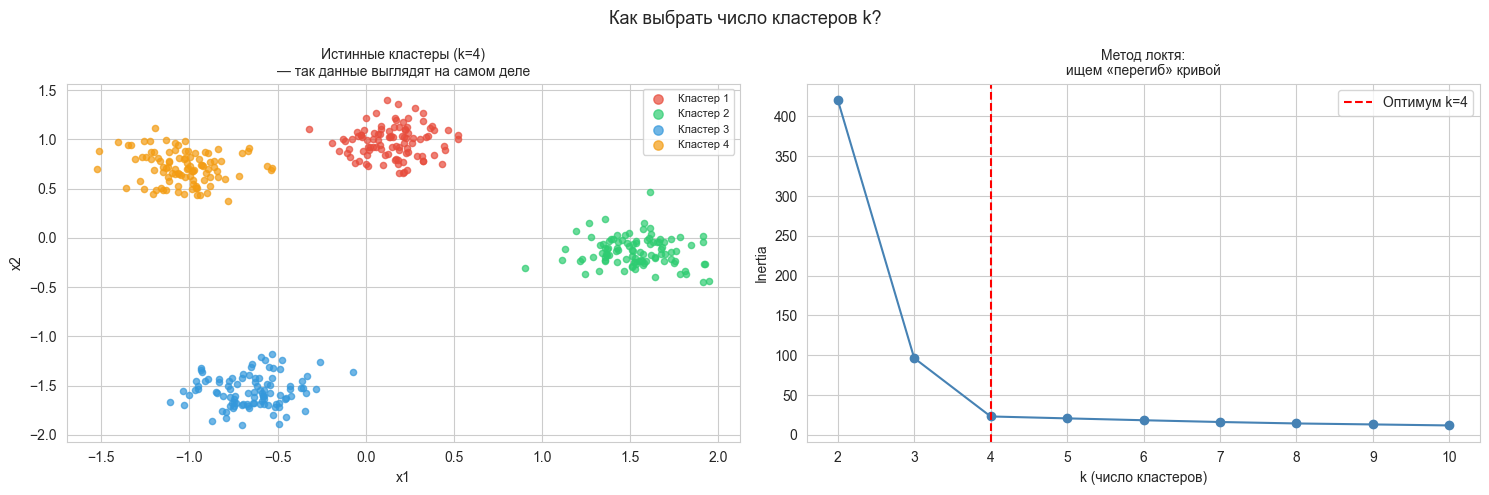

In [36]:
# Метод локтя 
np.random.seed(42)
X_elbow, y_true = make_blobs(n_samples=400, centers=4, cluster_std=1.0, random_state=42)
X_elbow_s = StandardScaler().fit_transform(X_elbow)

inertias, sil_scores = [], []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X_elbow_s)
    inertias.append(km.inertia_)

colors_4 = ['#e74c3c', '#2ecc71', '#3498db', '#f39c12']

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# --- График 1: истинные кластеры ---
for j in range(4):
    mask = y_true == j
    axes[0].scatter(X_elbow_s[mask, 0], X_elbow_s[mask, 1],
                    c=colors_4[j], s=20, alpha=0.7, label=f'Кластер {j+1}')
axes[0].set_title('Истинные кластеры (k=4)\n— так данные выглядят на самом деле', fontsize=10)
axes[0].set_xlabel('x1'); axes[0].set_ylabel('x2')
axes[0].legend(fontsize=8, markerscale=1.5)

# --- График 2: метод локтя ---
axes[1].plot(k_range, inertias, 'o-', color='steelblue', markersize=6)
axes[1].axvline(4, color='red', linestyle='--', label='Оптимум k=4')
axes[1].set_xlabel('k (число кластеров)')
axes[1].set_ylabel('Inertia')
axes[1].set_title('Метод локтя:\nищем «перегиб» кривой', fontsize=10)
axes[1].legend()

plt.suptitle('Как выбрать число кластеров k?', fontsize=13)
plt.tight_layout()
plt.show()


**Что мы видим:**  

как интерпретировать правый график?

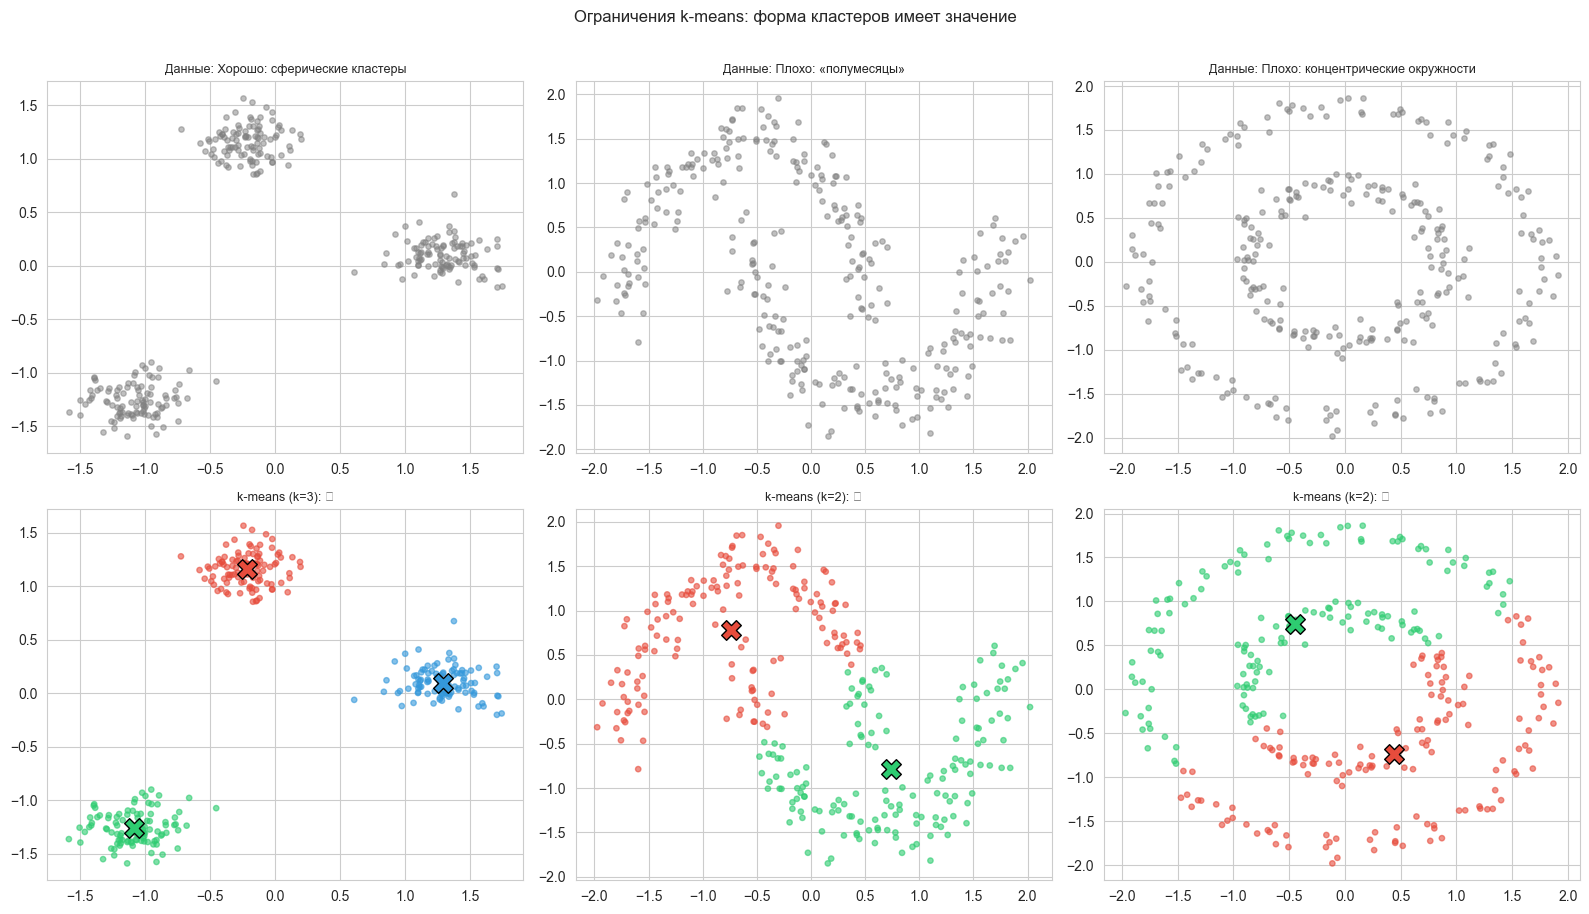

In [37]:
# Демонстрация проблемы k-means с нестандартными формами
from sklearn.datasets import make_moons, make_circles

fig, axes = plt.subplots(2, 3, figsize=(16, 9))

datasets = [
    (make_blobs(n_samples=300, centers=3, random_state=42)[0], 3, 'Хорошо: сферические кластеры'),
    (make_moons(n_samples=300, noise=0.1, random_state=42)[0], 2, 'Плохо: «полумесяцы»'),
    (make_circles(n_samples=300, noise=0.05, factor=0.5, random_state=42)[0], 2, 'Плохо: концентрические окружности'),
]

for col, (X_d, k_d, title_d) in enumerate(datasets):
    X_d_s = StandardScaler().fit_transform(X_d)
    km_d = KMeans(n_clusters=k_d, random_state=42, n_init=10).fit(X_d_s)
    colors_d = ['#e74c3c', '#2ecc71', '#3498db']
    point_c = [colors_d[l] for l in km_d.labels_]

    axes[0, col].scatter(X_d_s[:, 0], X_d_s[:, 1], c='gray', s=15, alpha=0.5)
    axes[0, col].set_title(f'Данные: {title_d}', fontsize=9)

    axes[1, col].scatter(X_d_s[:, 0], X_d_s[:, 1], c=point_c, s=15, alpha=0.6)
    for j, (cx, cy) in enumerate(km_d.cluster_centers_):
        axes[1, col].scatter(cx, cy, marker='X', s=200, c=colors_d[j], edgecolors='black', zorder=5)
    axes[1, col].set_title(f'k-means (k={k_d}): {"✓" if col == 0 else "✗"}', fontsize=9)

plt.suptitle('Ограничения k-means: форма кластеров имеет значение', fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

**Что мы видим:**  

Почему так происходит?

в чём математический смысл ошибки?


### Применим к данным с "Титаника"

Для сравнения полученных меток с реальными применим `pd.crosstab(df['cluster'], df['survived'])`

| Кластер | Погиб (0) | Выжил (1) |
|---|---|---|
| Кластер 0 | 80 | 140 |
| Кластер 1 | 344 | 150 |

Строки — значения первой переменной, столбцы — второй, в ячейках — количество совпадений. В нашем случае: сколько пассажиров из каждого кластера погибло и выжило.

По сути, это та же матрица ошибок — только без понятия «правильно/неправильно», просто пересечение двух разбиений на группы.

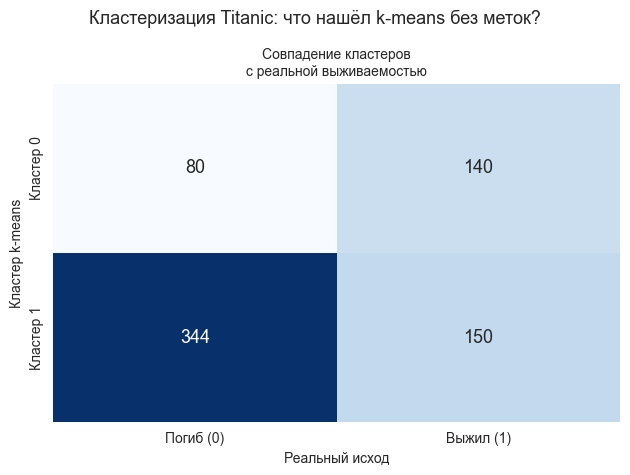

Средние значения признаков по кластерам:


,pclass,sex,age,fare,survived
cluster,,,,,
0,1.15,0.53,39.85,77.96,0.64
1,2.72,0.68,25.18,15.43,0.30


In [38]:
# Кластеризация пассажиров Титаника — без использования survived

features = ['pclass', 'sex', 'age', 'fare']
X_cl   = df_clean[features].values
scaler_cl = StandardScaler()
X_cl_s = scaler_cl.fit_transform(X_cl)

km_titanic = KMeans(n_clusters=2, random_state=42, n_init=10).fit(X_cl_s)
df_clean['cluster'] = km_titanic.labels_

# --- crosstab — насколько кластеры совпали с выживаемостью ---
ct = pd.crosstab(df_clean['cluster'], df_clean['survived'])
ct.index   = ['Кластер 0', 'Кластер 1']
ct.columns = ['Погиб (0)', 'Выжил (1)']
sns.heatmap(ct, annot=True, fmt='d', cmap='Blues', cbar=False,
            annot_kws={'size': 13})
plt.xlabel('Реальный исход'); 
plt.ylabel('Кластер k-means')
plt.title('Совпадение кластеров\nс реальной выживаемостью', fontsize=10)

plt.suptitle('Кластеризация Titanic: что нашёл k-means без меток?', fontsize=13)
plt.tight_layout()
plt.show()

# --- Содержательная интерпретация ---
print("Средние значения признаков по кластерам:")
df_clean.groupby('cluster')[features + ['survived']].mean().round(2)

**Что мы видим?**

Как интерпретировать эти кластеры? Насколько похожи они на реальные данные?

---
## DBSCAN — когда k-means не справляется

k-means плохо работает с кластерами невыпуклой формы (полумесяцы, кольца).  
**DBSCAN** (Density-Based Spatial Clustering) решает эту проблему.

### Идея

Вместо расстояния до центроида DBSCAN смотрит на **плотность точек**:
- Точка — **ядро**, если в радиусе `eps` вокруг неё не менее `min_samples` соседей.
- Точки, достижимые из ядра, образуют кластер.
- Точки без соседей — **шум** (метка `-1`).

### Параметры

| Параметр | Смысл | Как выбрать |
|---|---|---|
| `eps` | Радиус «окрестности» | Перебором; начните с 0.3–0.5 после масштабирования |
| `min_samples` | Минимум точек для ядра | Обычно 5; больше → меньше кластеров, меньше шума |

### Главное преимущество перед k-means

- Не нужно задавать k заранее
- Находит кластеры произвольной формы
- Автоматически выделяет выбросы (шум)


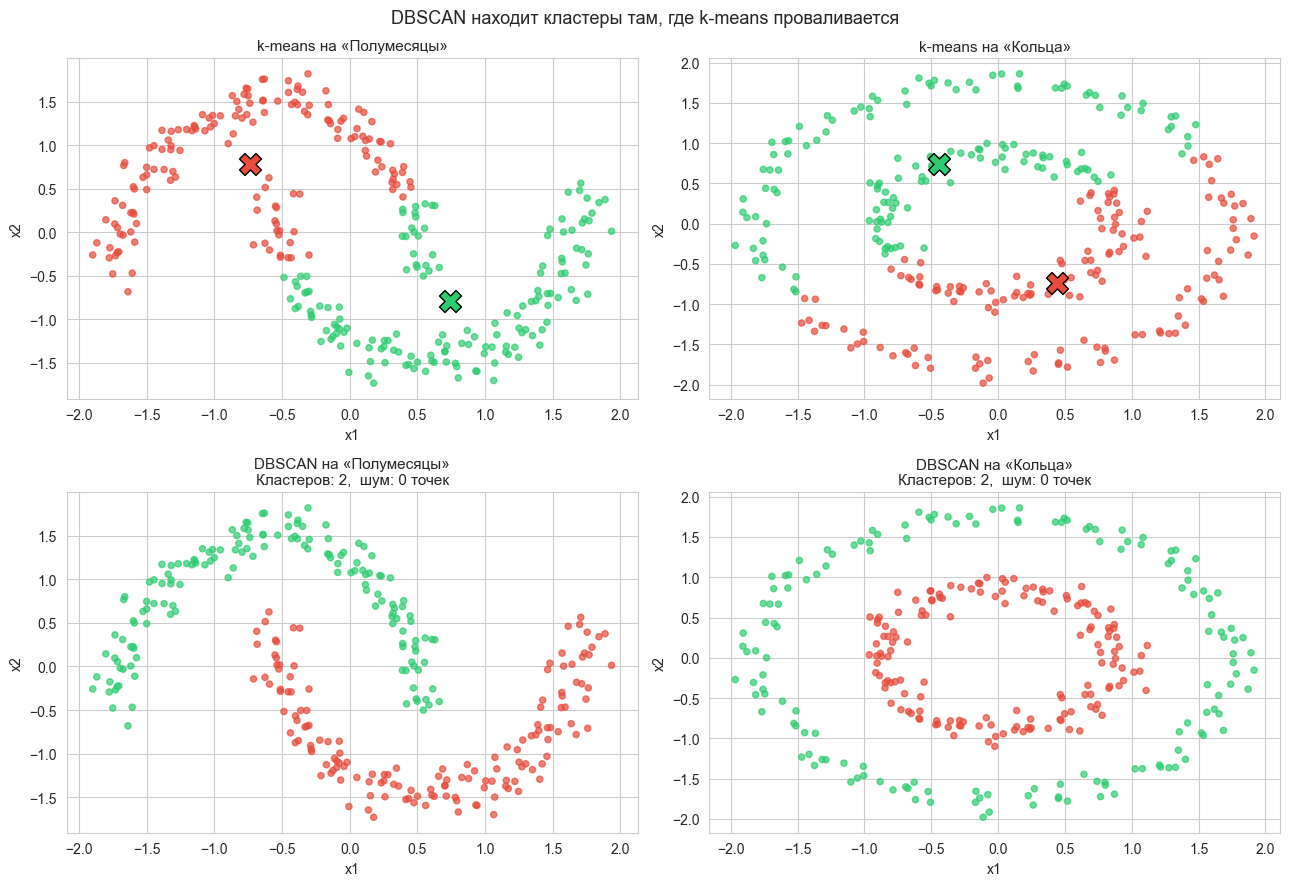

In [39]:
# DBSCAN vs k-means на нестандартных формах
from sklearn.datasets import make_moons, make_circles
from sklearn.cluster import DBSCAN

# DBSCAN vs k-means на нестандартных формах
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

datasets = [
    (make_moons(n_samples=300, noise=0.07, random_state=42)[0],          'Полумесяцы'),
    (make_circles(n_samples=300, noise=0.05, factor=0.5, random_state=42)[0], 'Кольца'),
]

palette = ['#e74c3c', '#2ecc71', '#3498db', '#9b59b6', '#f39c12']

for col, (X_d, title_d) in enumerate(datasets):
    X_d_s = StandardScaler().fit_transform(X_d)

    # k-means
    km_d = KMeans(n_clusters=2, random_state=42, n_init=10).fit(X_d_s)
    point_c_km = [palette[l] for l in km_d.labels_]
    axes[0, col].scatter(X_d_s[:, 0], X_d_s[:, 1], c=point_c_km, s=20, alpha=0.7)
    for j, (cx, cy) in enumerate(km_d.cluster_centers_):
        axes[0, col].scatter(cx, cy, marker='X', s=250, c=palette[j],
                             edgecolors='black', zorder=5)
    axes[0, col].set_title(f'k-means на «{title_d}»', fontsize=11)

    # DBSCAN — eps=0.35 даёт ровно 2 кластера для обоих датасетов
    db = DBSCAN(eps=0.35, min_samples=5).fit(X_d_s)
    cluster_ids = [l for l in set(db.labels_) if l != -1]
    # строим маппинг: id кластера → цвет, шум → чёрный
    color_map = {l: palette[i] for i, l in enumerate(cluster_ids)}
    point_c_db = [color_map[l] if l != -1 else 'black' for l in db.labels_]
    axes[1, col].scatter(X_d_s[:, 0], X_d_s[:, 1], c=point_c_db, s=20, alpha=0.7)
    n_noise = list(db.labels_).count(-1)
    axes[1, col].set_title(
        f'DBSCAN на «{title_d}»\n'
        f'Кластеров: {len(cluster_ids)},  шум: {n_noise} точек', fontsize=11)

for ax in axes.flat:
    ax.set_xlabel('x1'); ax.set_ylabel('x2')

plt.suptitle('DBSCAN находит кластеры там, где k-means проваливается', fontsize=13)
plt.tight_layout()
plt.show()

**Когда использовать DBSCAN вместо k-means:**
- Кластеры явно неправильной формы
- Вы не знаете k заранее
- В данных есть выбросы, которые нужно выявить


---
## Шпаргалка

### Выбор алгоритма

| Задача | Метки известны? | Алгоритм |
|---|---|---|
| Предсказать 0/1 | Да | Логистическая регрессия, KNN |
| Найти группы (сферические) | Нет | k-means |
| Найти группы (любая форма) | Нет | DBSCAN |
| Предсказать число | Да | Линейная регрессия |

### Ключевые метрики

```
Accuracy  = (TP + TN) / всего       — общая доля верных (осторожно при дисбалансе!)
Precision = TP / (TP + FP)          — из предсказанных «+», сколько верно  → важна при дорогом FP
Recall    = TP / (TP + FN)          — из реальных «+», сколько нашли       → важна при дорогом FN
AUC       ∈ [0.5, 1.0]              — качество ранжирования, не зависит от порога
```

### Когда масштабировать?

| Алгоритм | Нужен StandardScaler? |
|---|---|
| Логистическая регрессия | ✅ Да |
| KNN | ✅ Да (расстояния!) |
| k-means | ✅ Да (расстояния!) |
| DBSCAN | ✅ Да |

### Золотые правила

1. `scaler.fit_transform(X_train)` → `scaler.transform(X_test)` — **никогда не fit на test**
2. Выбирать k для KNN — по валидационной выборке, **не по тестовой**
3. Для k-means всегда `n_init=10` — несколько стартов, берём лучший
4. Дисбаланс классов → смотрим Precision и Recall, а не только accuracy
5. Не знаете k заранее или кластеры неправильной формы → DBSCAN
